<a href="https://colab.research.google.com/github/nexageapps/AI/blob/main/Basic/B05%20-%20Neural%20Network%20Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 5: Neural Network Fundamentals

**Interactive Apps:** [Neural Network Explorer](https://nexageapps.github.io/AI/neural-network/) | [Neural Network Trainer](https://nexageapps.github.io/AI/nn-trainer/)

**MAI Alignment:** COMPSCI 714 (Lecture 2-3), COMPSYS 721 | **Next Level:** [I01 - Advanced Optimization](../Intermediate/I01%20-%20Advanced%20Optimization%20Algorithms.ipynb), [I03 - Batch Normalization](../Intermediate/I03%20-%20Batch%20and%20Layer%20Normalization.ipynb)


## Learning Objectives
- Understand multi-layer perceptrons (MLPs)
- Learn about hidden layers and their purpose
- Explore activation functions (ReLU, tanh, sigmoid)
- Understand overfitting vs underfitting
- Implement dropout and regularization

## Prerequisites
- Completed L1-L5
- Understanding of multi-class classification

### Interactive Apps
- [Neural Network Explorer](https://nexageapps.github.io/AI/neural-network/) — Build and visualise neural networks, explore activation functions, and learn about logical neural networks

**COMPSCI 714 PyTorch Practice:** [B05c - MLP on Tabular Data with PyTorch](./B05c%20-%20MLP%20on%20Tabular%20Data%20with%20PyTorch%20(COMPSCI%20714).ipynb) — PyTorch MLP, BCEWithLogitsLoss, Optuna tuning, FashionMNIST CNN, saliency maps

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns
import os

print(f"TensorFlow version: {tf.__version__}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

2026-05-24 22:07:54.541530: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2


## 1. Why Do We Need Hidden Layers?

In L5, we used a single layer (input → output).  
This is called a **linear model** and can only learn linear patterns.

**Problem:** Real-world data is rarely linear!

**Solution:** Add hidden layers to learn complex, non-linear patterns.

### Architecture Evolution:
- **L5:** Input (784) → Output (10)
- **L6:** Input (784) → Hidden (128) → Output (10)

## 2. Understanding Activation Functions

Activation functions introduce **non-linearity** into the network.

Without activation functions, multiple layers = one layer (just matrix multiplication).

### Common Activation Functions:
1. **ReLU** (Rectified Linear Unit): `f(x) = max(0, x)`
2. **Sigmoid**: `f(x) = 1 / (1 + e^(-x))`
3. **Tanh**: `f(x) = (e^x - e^(-x)) / (e^x + e^(-x))`
4. **Softmax**: Used for output layer in multi-class classification

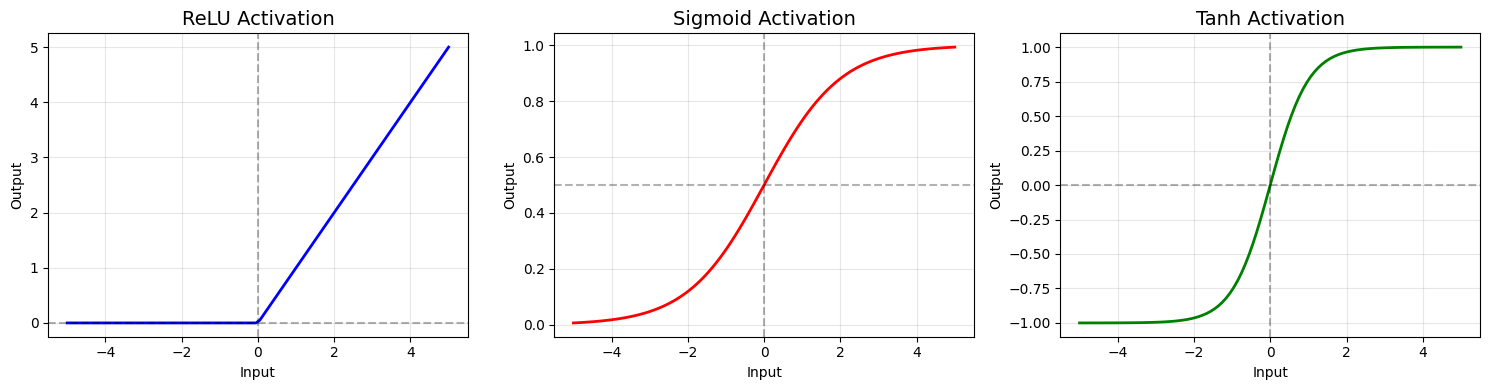

Activation Function Properties:

ReLU:
  - Range: [0, ∞)
  - Fast to compute
  - Most popular for hidden layers
  - Can suffer from 'dying ReLU' problem

Sigmoid:
  - Range: (0, 1)
  - Good for binary classification output
  - Can cause vanishing gradients

Tanh:
  - Range: (-1, 1)
  - Zero-centered (better than sigmoid)
  - Can also cause vanishing gradients


In [2]:
# Visualize activation functions
x = np.linspace(-5, 5, 100)

# Define activation functions
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

# Plot
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(x, relu, 'b-', linewidth=2)
plt.title('ReLU Activation', fontsize=14)
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(x, sigmoid, 'r-', linewidth=2)
plt.title('Sigmoid Activation', fontsize=14)
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(x, tanh, 'g-', linewidth=2)
plt.title('Tanh Activation', fontsize=14)
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("Activation Function Properties:")
print("\nReLU:")
print("  - Range: [0, ∞)")
print("  - Fast to compute")
print("  - Most popular for hidden layers")
print("  - Can suffer from 'dying ReLU' problem")

print("\nSigmoid:")
print("  - Range: (0, 1)")
print("  - Good for binary classification output")
print("  - Can cause vanishing gradients")

print("\nTanh:")
print("  - Range: (-1, 1)")
print("  - Zero-centered (better than sigmoid)")
print("  - Can also cause vanishing gradients")

## 3. Load and Prepare Data

In [3]:
# Load MNIST dataset
#(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


print("Current folder:", os.getcwd())
if "mnist.npz" in os.listdir():
    print("mnist.npz found")
else:
    print("mnist.npz not found in current folder")


# Load MNIST from local mnist.npz file
with np.load("mnist.npz", allow_pickle=True) as data:
    x_train = data["x_train"]
    y_train = data["y_train"]
    x_test = data["x_test"]
    y_test = data["y_test"]


# Normalize and flatten
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode labels
y_train_onehot = keras.utils.to_categorical(y_train, 10)
y_test_onehot = keras.utils.to_categorical(y_test, 10)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

Current folder: /Users/arjunkarthik/Applications/MAI/AI/AI/Basic
mnist.npz found
Training data shape: (60000, 784)
Test data shape: (10000, 784)


## 4. Build a Multi-Layer Neural Network

Let's compare different architectures:
1. Single layer (from L5)
2. One hidden layer
3. Two hidden layers

In [4]:
# Model 1: Single Layer (No hidden layers)
model_single = keras.Sequential([
    layers.Dense(10, activation='softmax', input_shape=(784,))
], name='Single_Layer')

# Model 2: One Hidden Layer
model_one_hidden = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
], name='One_Hidden_Layer')

# Model 3: Two Hidden Layers
model_two_hidden = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='Two_Hidden_Layers')

# Compile all models
for model in [model_single, model_one_hidden, model_two_hidden]:
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

print("Model 1: Single Layer")
model_single.summary()
print("\n" + "="*50 + "\n")

print("Model 2: One Hidden Layer")
model_one_hidden.summary()
print("\n" + "="*50 + "\n")

print("Model 3: Two Hidden Layers")
model_two_hidden.summary()

Model 1: Single Layer


/Users/arjunkarthik/Applications/MAI/AI/AI/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Single_Layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

...

Model: "Two_Hidden_Layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train and Compare Models

In [6]:
# Train all models
models = [model_single, model_one_hidden, model_two_hidden]
histories = []

for i, model in enumerate(models):
    print(f"\nTraining {model.name}...")
    history = model.fit(
        x_train, y_train_onehot,
        epochs=10,
        batch_size=128,
        validation_split=0.2,
        verbose=0
    )
    histories.append(history)
    
    # Evaluate
    test_loss, test_acc = model.evaluate(x_test, y_test_onehot, verbose=0)
    print(f"{model.name} - Test Accuracy: {test_acc*100:.2f}% and test loss is : {test_loss}")


Training Single_Layer...
Single_Layer - Test Accuracy: 92.70% and test loss is : 0.2648244798183441

Training One_Hidden_Layer...
One_Hidden_Layer - Test Accuracy: 97.66% and test loss is : 0.09225312620401382

Training Two_Hidden_Layers...
Two_Hidden_Layers - Test Accuracy: 97.99% and test loss is : 0.10765039920806885


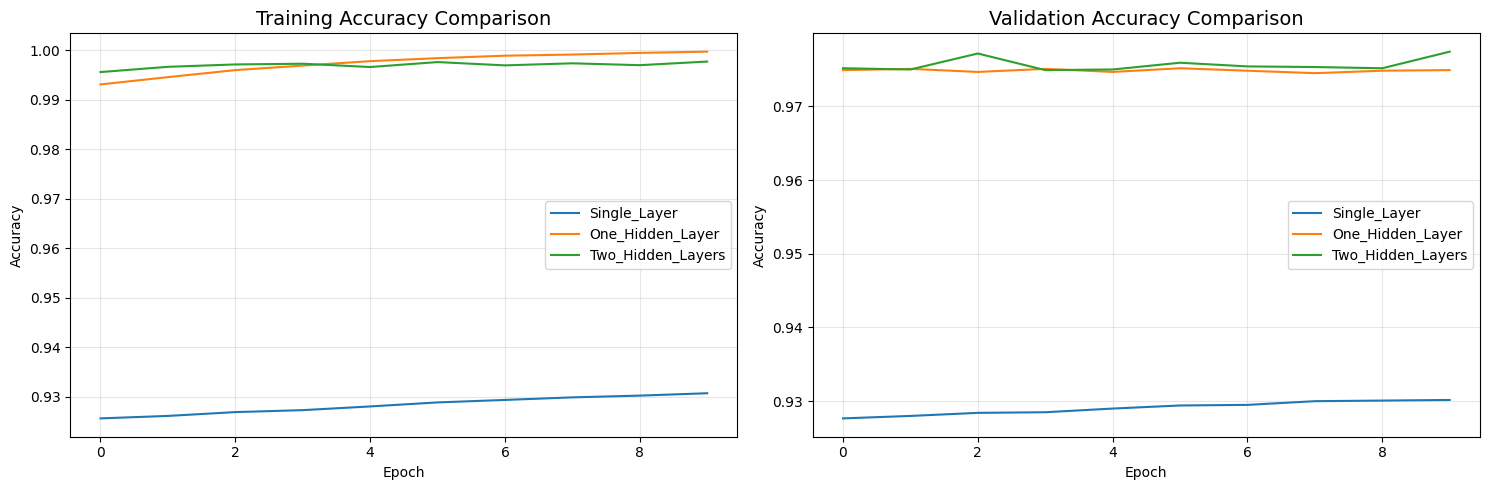

In [7]:
# Plot comparison
plt.figure(figsize=(15, 5))

# Training accuracy
plt.subplot(1, 2, 1)
for i, (model, history) in enumerate(zip(models, histories)):
    plt.plot(history.history['accuracy'], label=model.name)
plt.title('Training Accuracy Comparison', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Validation accuracy
plt.subplot(1, 2, 2)
for i, (model, history) in enumerate(zip(models, histories)):
    plt.plot(history.history['val_accuracy'], label=model.name)
plt.title('Validation Accuracy Comparison', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Understanding Overfitting vs Underfitting

### Underfitting:
- Model is too simple
- Poor performance on both training and test data
- **Solution:** Add more layers/neurons, train longer

### Overfitting:
- Model is too complex
- Great on training data, poor on test data
- **Solution:** Regularization, dropout, more data

### Good Fit:
- Good performance on both training and test data
- Small gap between training and validation accuracy

/Users/arjunkarthik/Applications/MAI/AI/AI/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training overfitting-prone model...


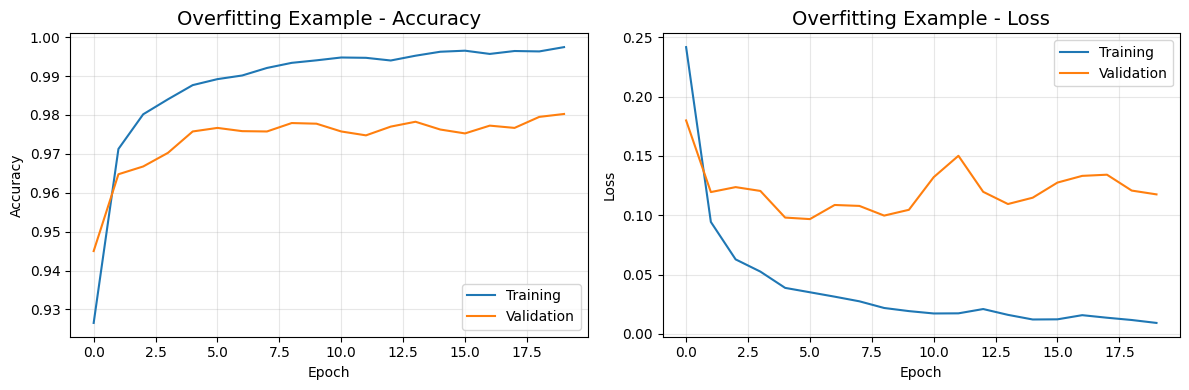


Notice how training accuracy keeps improving,
but validation accuracy plateaus or decreases.
This is a clear sign of OVERFITTING!


In [8]:
# Demonstrate overfitting with a very deep network
model_overfit = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='Overfitting_Model')

model_overfit.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training overfitting-prone model...")
history_overfit = model_overfit.fit(
    x_train, y_train_onehot,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=0
)

# Plot overfitting
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_overfit.history['accuracy'], label='Training')
plt.plot(history_overfit.history['val_accuracy'], label='Validation')
plt.title('Overfitting Example - Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_overfit.history['loss'], label='Training')
plt.plot(history_overfit.history['val_loss'], label='Validation')
plt.title('Overfitting Example - Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNotice how training accuracy keeps improving,")
print("but validation accuracy plateaus or decreases.")
print("This is a clear sign of OVERFITTING!")

## 7. Preventing Overfitting: Dropout

**Dropout** randomly "drops" neurons during training.
- Prevents neurons from co-adapting
- Acts as regularization
- Typical dropout rate: 0.2 - 0.5

Training model with dropout...


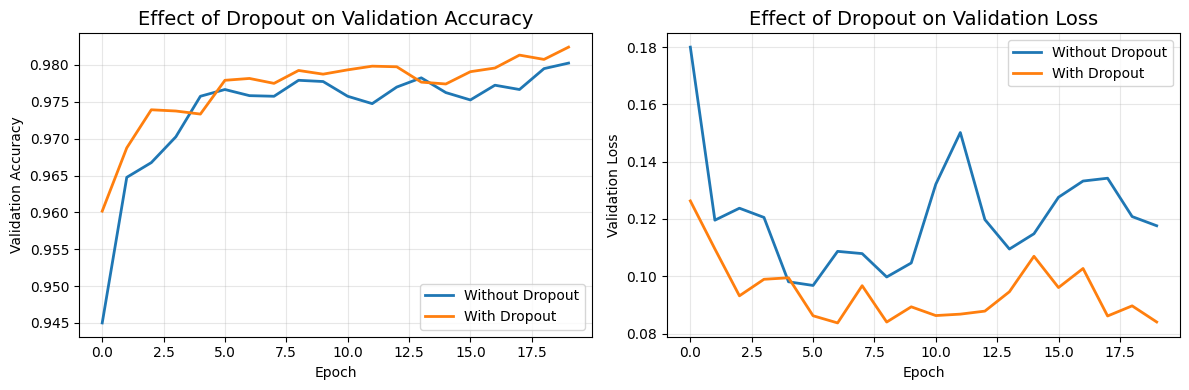

In [9]:
# Model with dropout
model_dropout = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),  # Drop 30% of neurons
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='Model_with_Dropout')

model_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training model with dropout...")
history_dropout = model_dropout.fit(
    x_train, y_train_onehot,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=0
)

# Compare with and without dropout
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_overfit.history['val_accuracy'], label='Without Dropout', linewidth=2)
plt.plot(history_dropout.history['val_accuracy'], label='With Dropout', linewidth=2)
plt.title('Effect of Dropout on Validation Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_overfit.history['val_loss'], label='Without Dropout', linewidth=2)
plt.plot(history_dropout.history['val_loss'], label='With Dropout', linewidth=2)
plt.title('Effect of Dropout on Validation Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Optimal Model Architecture

Let's build an optimal model with:
- Appropriate depth (2 hidden layers)
- Dropout for regularization
- Batch normalization for faster training

In [10]:
# Optimal model
model_optimal = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(10, activation='softmax')
], name='Optimal_Model')

model_optimal.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_optimal.summary()

# Train
print("\nTraining optimal model...")
history_optimal = model_optimal.fit(
    x_train, y_train_onehot,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluate
test_loss, test_acc = model_optimal.evaluate(x_test, y_test_onehot)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

Model: "Optimal_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,682 (924.54 KB)

 Trainable params: 235,914 (921.54 KB)

 Non-trainable params: 768 (3.00 KB)


Training optimal model...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8898 - loss: 0.3653 - val_accuracy: 0.9552 - val_loss: 0.1561
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9482 - loss: 0.1708 - val_accuracy: 0.9652 - val_loss: 0.1153
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9594 - loss: 0.1297 - val_accuracy: 0.9702 - val_loss: 0.0997
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9661 - loss: 0.1088 - val_accuracy: 0.9726 - val_loss: 0.0905
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9715 - loss: 0.0894 - val_accuracy: 0.9749 - val_loss: 0.0860
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9739 - loss: 0.0807 - val_accuracy: 0.9734 - val_loss: 0.0872
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9768 - loss: 0.0710 - val_accuracy: 0.9767 - val_loss: 0.0822
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9787 - 

## 9. Visualize Model Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


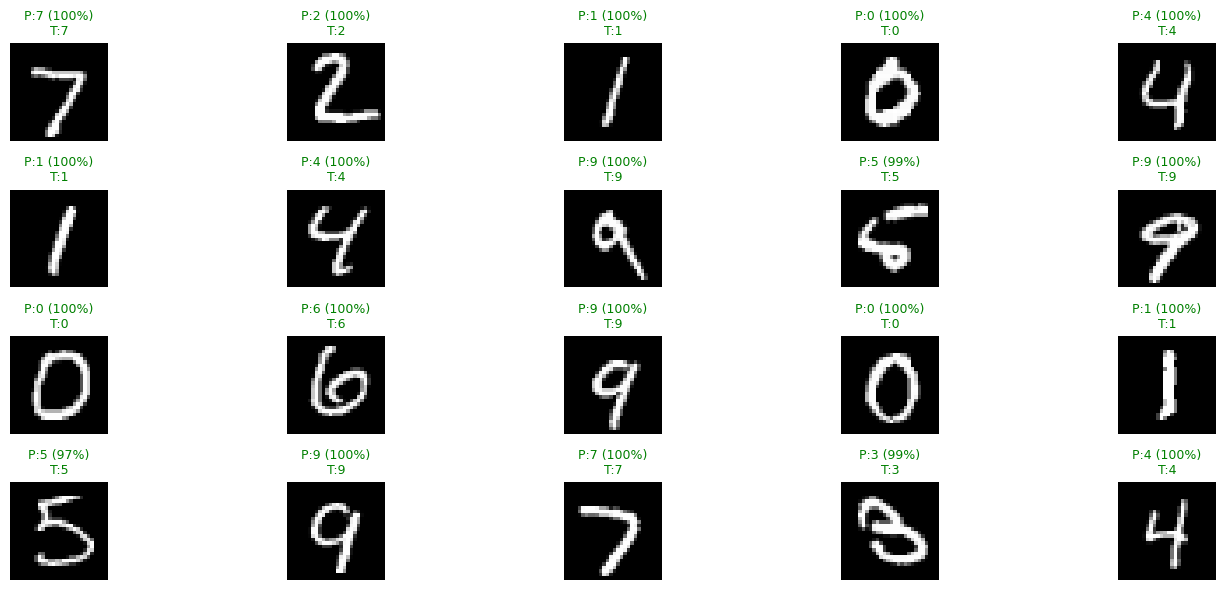

In [11]:
# Make predictions
predictions = model_optimal.predict(x_test[:20].reshape(-1, 784))

# Visualize
plt.figure(figsize=(15, 6))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]
    confidence = predictions[i][pred_label] * 100
    
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"P:{pred_label} ({confidence:.0f}%)\nT:{true_label}", 
              color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 10. Key Takeaways

### Architecture:
1. **Hidden layers** enable learning complex patterns
2. **ReLU** is the most common activation for hidden layers
3. **Deeper ≠ Better** - balance complexity with overfitting

### Training:
4. **Overfitting** occurs when model memorizes training data
5. **Dropout** prevents overfitting by randomly dropping neurons
6. **Batch Normalization** speeds up training and improves stability

### Best Practices:
7. Start simple, add complexity gradually
8. Monitor validation metrics to detect overfitting
9. Use dropout rates between 0.2-0.5
10. Experiment with different architectures

## Next Steps (L7)
- Learn about Convolutional Neural Networks (CNNs)
- Understand why CNNs are better for images
- Implement convolution and pooling layers

## References
- Deep Learning Book: https://www.deeplearningbook.org/
- CS231n Stanford: http://cs231n.stanford.edu/
- TensorFlow Tutorials: https://www.tensorflow.org/tutorials

---

## Exercises

Test your understanding with these hands-on exercises. Try to solve them before looking at the hints.


### Exercise 1: Activation Function Comparison

Build two identical neural networks for the XOR problem — one using **ReLU** activation and one using **sigmoid** activation in the hidden layers. Train both for the same number of epochs and compare:
1. Training loss curves
2. Final accuracy
3. Number of epochs to converge



In [ ]:
import tensorflow as tf
import numpy as np

# XOR data
X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# Model 1: ReLU hidden layers
# model_relu = tf.keras.Sequential([...])

# Model 2: Sigmoid hidden layers
# model_sigmoid = tf.keras.Sequential([...])

# Train both and compare
# Your code here


### Exercise 2: Network Depth Experiment

Using the MNIST dataset, build three models with different depths:
- Shallow: 1 hidden layer (128 units)
- Medium: 2 hidden layers (128, 64 units)
- Deep: 4 hidden layers (256, 128, 64, 32 units)

Train each for 10 epochs and compare test accuracy. Does deeper always mean better?



In [ ]:
# Load MNIST
# (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
# X_train, X_test = X_train / 255.0, X_test / 255.0

# Build three models with different depths
# Train and compare test accuracy
# Your code here


---

## Key Takeaways

**Relevant UoA Courses:** COMPSCI 713, COMPSCI 762, COMPSYS 721

1. MLPs have input layer, hidden layer(s), and output layer
2. Each layer: z = Wx + b, then a = activation(z)
3. ReLU activation: f(x) = max(0, x) - most common for hidden layers
4. Backpropagation computes gradients layer by layer using chain rule
5. Universal approximation theorem: MLPs can approximate any function

---

## Exam Preparation Guide

### Essential Concepts for Exams

- Trace forward pass through network: input → hidden → output
- Calculate number of parameters: (input_dim × hidden_dim) + hidden_dim + ...
- Understand vanishing gradient problem with sigmoid/tanh
- Know why ReLU is preferred: no vanishing gradient, computationally efficient
- Be able to apply chain rule for backpropagation

### Common Mistakes to Avoid

- ❌ Forgetting bias terms when counting parameters
- ❌ Using sigmoid in hidden layers (causes vanishing gradients)
- ❌ Not understanding that deeper ≠ always better

### Practice Problems

1. Network: 784 → 128 → 64 → 10. How many parameters?
2. Given ReLU(Wx + b) where x=[1,-2], W=[[2,1]], b=[0], compute output
3. Explain why ReLU(x) = max(0,x) helps with vanishing gradients

### How This Helps Your UoA Courses

**COMPSCI 713, COMPSCI 762, COMPSYS 721:**
- Provides hands-on implementation of theoretical concepts
- Practice problems similar to exam questions
- Reinforces lecture material with code examples
- Helps build intuition for complex topics

### Study Tips

1. **Understand, Don't Memorize**: Focus on why, not just what
2. **Practice Calculations**: Work through problems by hand
3. **Connect to Theory**: Link code to mathematical formulations
4. **Teach Others**: Explaining concepts solidifies understanding
5. **Review Regularly**: Spaced repetition improves retention

### Exam Question Types

- **Conceptual**: Explain why/how something works
- **Calculation**: Compute outputs, gradients, shapes
- **Comparison**: Compare approaches, trade-offs
- **Application**: Design solution for given problem
- **Debugging**: Identify and fix issues

---


---

## Learning Progress Tracker

Use this section to track your learning progress for this lesson.

### Completion Status
- [ ] Lesson completed
- [ ] All code cells executed successfully
- [ ] Understood all key concepts
- [ ] Completed practice exercises (if any)

### Dates
- **First Completed:** ____/____/____
- **Last Reviewed:** ____/____/____
- **Next Review:** ____/____/____ (Recommended: 1 week, 1 month, 3 months)

### Understanding Level
Rate your understanding (1-5): _____ / 5

- 1 = Need to review completely
- 2 = Understood basics, need more practice
- 3 = Good understanding, minor gaps
- 4 = Strong understanding, can explain to others
- 5 = Mastered, can apply in projects

### Notes & Reflections
```
Write your notes here:
- What concepts were challenging?
- What was interesting or surprising?
- How can you apply this in projects?
- Questions to explore further?




```

### Key Concepts to Remember (B05)
- [ ] Multi-layer perceptrons (MLPs)
- [ ] Activation functions (ReLU, sigmoid, tanh)
- [ ] Backpropagation algorithm
- [ ] Forward and backward passes

---